In [54]:
import pandas as pd 

df = pd.read_csv('/kaggle/input/datasets/ridwanul02/mail-customers/Mall_Customers (1).csv')
df_unchanged = pd.read_csv('/kaggle/input/datasets/ridwanul02/mail-customers/Mall_Customers (1).csv')

df.shape

(200, 5)

In [55]:
df_unchanged.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [56]:
df = df.rename(columns={
    'Annual Income (k$)': 'Annual Income',
    'Spending Score (1-100)': 'Spending Score',
    'CustomerID': 'Customer ID'
})

df.head()

,Customer ID,Gender,Age,Annual Income,Spending Score
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [57]:
df.describe()

,Customer ID,Age,Annual Income,Spending Score
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [58]:
print('Data types:')
print(df.dtypes)
print()
print('Missing values:')
print(df.isnull().sum())

Data types:
Customer ID        int64
Gender            object
Age                int64
Annual Income      int64
Spending Score     int64
dtype: object

Missing values:
Customer ID       0
Gender            0
Age               0
Annual Income     0
Spending Score    0
dtype: int64


In [59]:
df.columns

Index(['Customer ID', 'Gender', 'Age', 'Annual Income', 'Spending Score'], dtype='object')

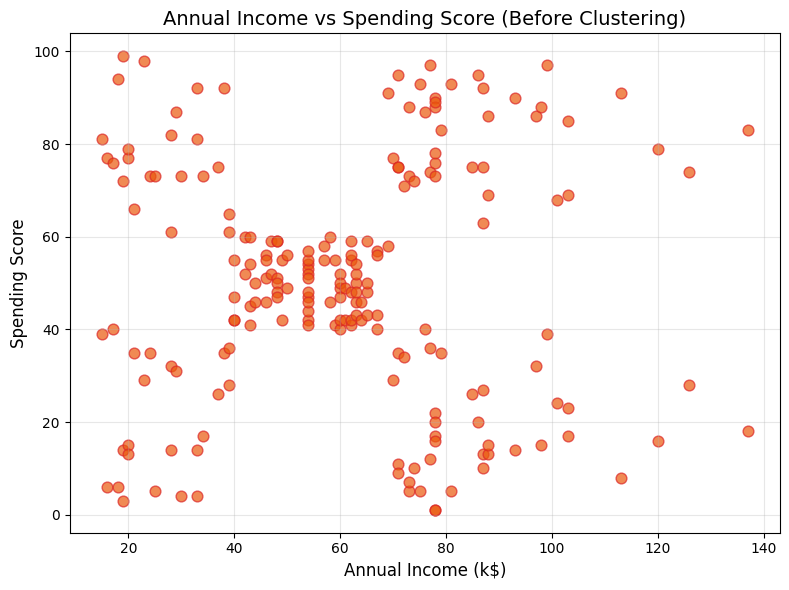

In [60]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.scatter(df['Annual Income'], df['Spending Score'],
            s=60, color='#EA580C',edgecolor='#DC2626', alpha=0.7)
plt.xlabel('Annual Income (k$)', fontsize=12)
plt.ylabel('Spending Score', fontsize=12)
plt.title('Annual Income vs Spending Score (Before Clustering)', fontsize=14)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [61]:
from sklearn.preprocessing import StandardScaler

X = df[['Annual Income', 'Spending Score']]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [62]:
from sklearn.cluster import KMeans

inertias = []
k_range = range(2, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init='auto')
    km.fit(X_scaled)
    inertias.append(km.inertia_)

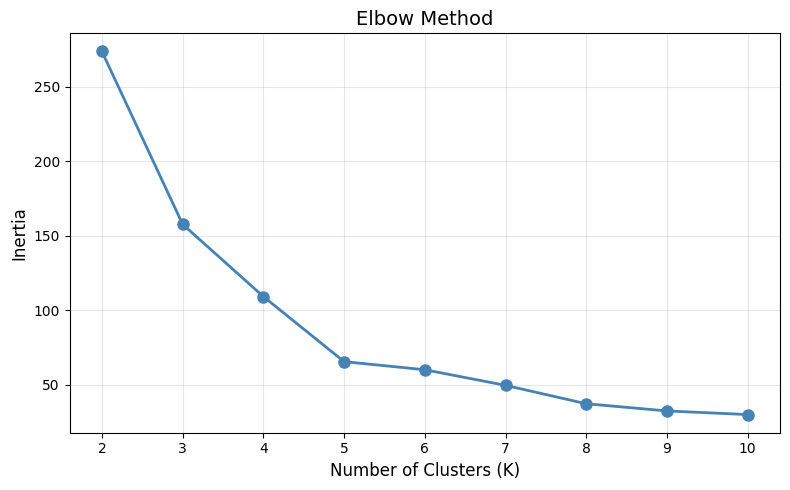

In [63]:
plt.figure(figsize=(8, 5))
plt.plot(k_range, inertias, marker='o', color='steelblue', linewidth=2, markersize=8)
plt.xlabel('Number of Clusters (K)', fontsize=12)
plt.ylabel('Inertia', fontsize=12)
plt.title('Elbow Method', fontsize=14)
plt.xticks(k_range)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [64]:
K = 5 

km = KMeans(n_clusters=k, random_state=42, n_init='auto')
df['Cluster'] = km.fit_predict(X_scaled)

In [65]:
centroids = scaler.inverse_transform(km.cluster_centers_)
centroids

array([[ 62.58333333,  47.29166667],
       [ 97.09090909,  86.09090909],
       [ 79.73913043,  13.39130435],
       [ 24.95      ,  81.        ],
       [ 24.58333333,   9.58333333],
       [ 76.96      ,  80.8       ],
       [ 45.89189189,  52.37837838],
       [109.7       ,  22.        ],
       [ 28.18181818,  33.27272727],
       [127.66666667,  78.66666667]])

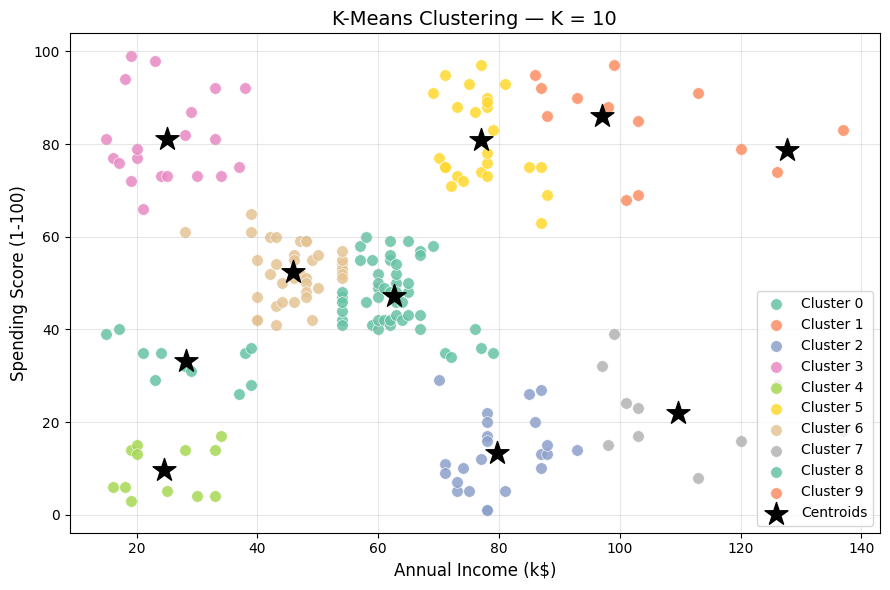

In [66]:
import matplotlib.pyplot as plt
import seaborn as sns

unique_clusters = sorted(df['Cluster'].unique())
num_clusters = len(unique_clusters)
palette = sns.color_palette('Set2', num_clusters)

plt.figure(figsize=(9, 6))

for i, cluster in enumerate(unique_clusters):
    subset = df[df['Cluster'] == cluster]
    plt.scatter(
        subset['Annual Income'],
        subset['Spending Score'],
        label=f'Cluster {cluster}',
        color=palette[i],
        s=70,
        alpha=0.85,
        edgecolors='white',
        linewidth=0.5,
    )

plt.scatter(
    centroids[:, 0],
    centroids[:, 1],
    marker='*',
    s=300,
    color='black',
    label='Centroids',
    zorder=5,
)

plt.xlabel('Annual Income (k$)', fontsize=12)
plt.ylabel('Spending Score (1-100)', fontsize=12)
plt.title(f'K-Means Clustering — K = {num_clusters}', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [67]:
profile = df.groupby('Cluster')[['Age', 'Annual Income', 'Spending Score']].mean().round(1)
profile.insert(0, 'Count', df.groupby('Cluster').size())
profile

,Count,Age,Annual Income,Spending Score
Cluster,,,,
0,48,42.2,62.6,47.3
1,11,32.6,97.1,86.1
2,23,40.2,79.7,13.4
3,20,24.8,25.0,81.0
4,12,48.8,24.6,9.6
5,25,32.8,77.0,80.8
6,37,43.1,45.9,52.4
7,10,41.0,109.7,22.0
8,11,41.4,28.2,33.3


In [68]:
%%writefile app.py
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import streamlit as st
from kneed import KneeLocator
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# ── 1. Page Configuration (Slide 29) ─────────────────────────
st.set_page_config(
    page_title="Customer Segmentation App", page_icon="🛍️", layout="wide"
)

# ── 2. Session State Management (Slide 28) ────────────────────
if "k_value" not in st.session_state:
  st.session_state["k_value"] = 5


def set_k(val: int):
  st.session_state["k_value"] = int(val)


# ── 3. Cached Data Loading (Slide 27) ─────────────────────────
@st.cache_data
def load_data():
  df = pd.read_csv("data/customers.csv")
  df.columns = df.columns.str.strip()
  df = df.rename(
      columns={
          "Annual Income (k$)": "Annual Income",
          "Spending Score (1-100)": "Spending Score",
          "CustomerID": "Customer ID",
      }
  )
  return df


df = load_data()

# ── 4. Sidebar Controls (Slide 25 & 29) ───────────────────────
st.sidebar.header("Settings")

k = st.sidebar.slider(
    "Number of Clusters (K)",
    min_value=2,
    max_value=10,
    step=1,
    key="k_value",
)

# ── 5. Title & Dataset Overview ───────────────────────────────
st.title("🛍️ Mall Customer Segmentation App")
st.markdown(
    "This application performs customer segmentation using **K-Means"
    " Clustering**."
)

st.header("1. Dataset Overview")
col1, col2, col3, col4 = st.columns(4)
col1.metric("Total Customers", len(df))
col2.metric("Age Range", f"{df['Age'].min()}–{df['Age'].max()}")
col3.metric(
    "Income Range",
    f"{df['Annual Income'].min()}k–{df['Annual Income'].max()}k",
)
col4.metric(
    "Spending Score Range",
    f"{df['Spending Score'].min()}–{df['Spending Score'].max()}",
)

st.dataframe(df.head(10), use_container_width=True)

# ── 6. Feature Scaling (Slide 6 & 19) ─────────────────────────
X_raw = df[["Annual Income", "Spending Score"]].values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

# ── 7. Elbow Method Section (Slide 17 & 32) ───────────────────
st.markdown("---")
st.header("2. Elbow Method — Choosing K")

ks = list(range(2, 11))
inertias = []
for kk in ks:
  km_tmp = KMeans(n_clusters=kk, random_state=42, n_init="auto")
  km_tmp.fit(X_scaled)
  inertias.append(km_tmp.inertia_)

knee = KneeLocator(ks, inertias, curve="convex", direction="decreasing")
optimal_k = knee.knee

col_left, col_right = st.columns([2, 1])

with col_left:
  fig_elbow, ax_elbow = plt.subplots(figsize=(7, 4), dpi=120)
  ax_elbow.plot(
      ks, inertias, marker="o", color="steelblue", linewidth=2, markersize=8
  )
  ax_elbow.axvline(
      st.session_state["k_value"],
      color="orange",
      linestyle="--",
      linewidth=2,
      label=f"Selected K = {st.session_state['k_value']}",
  )
  ax_elbow.set_xlabel("Number of Clusters (K)", fontsize=11)
  ax_elbow.set_ylabel("Inertia", fontsize=11)
  ax_elbow.set_title("Elbow Curve", fontsize=13)
  ax_elbow.legend()
  ax_elbow.grid(True, linestyle="--", alpha=0.3)
  plt.tight_layout()
  st.pyplot(fig_elbow, use_container_width=True)

with col_right:
  st.markdown("### Suggested K")
  if optimal_k is not None:
    st.metric("Optimal K (KneeLocator)", int(optimal_k))
    st.button(
        "Use suggested K",
        on_click=set_k,
        args=(int(optimal_k),),
        key="use_optimal_k_btn",
    )
  else:
    st.warning("No clear elbow found.")

# ── 8. Dynamic K-Means Execution & Plotting (Slide 26) ────────
st.markdown("---")
st.header(f"3. Dynamic K-Means Clustering — K = {st.session_state['k_value']}")

km = KMeans(
    n_clusters=int(st.session_state["k_value"]), random_state=42, n_init="auto"
)
labels = km.fit_predict(X_scaled)

df_out = df.copy()
df_out["Cluster"] = labels
df_out["Cluster"] = df_out["Cluster"].apply(lambda x: f"Cluster {x+1}")

centers = scaler.inverse_transform(km.cluster_centers_)

st.subheader("Cluster Visualization")
fig_scatter, ax_scatter = plt.subplots(figsize=(9, 5), dpi=120)
palette = sns.color_palette("Set2", st.session_state["k_value"])

for i, cluster in enumerate(sorted(df_out["Cluster"].unique())):
  subset = df_out[df_out["Cluster"] == cluster]
  ax_scatter.scatter(
      subset["Annual Income"],
      subset["Spending Score"],
      label=cluster,
      color=palette[i],
      s=60,
      alpha=0.85,
      edgecolors="white",
      linewidth=0.5,
  )

ax_scatter.scatter(
    centers[:, 0],
    centers[:, 1],
    marker="*",
    s=300,
    color="black",
    label="Centroid",
    zorder=5,
)
ax_scatter.set_xlabel("Annual Income (k$)", fontsize=11)
ax_scatter.set_ylabel("Spending Score (1-100)", fontsize=11)
ax_scatter.set_title("Annual Income vs Spending Score", fontsize=13)
ax_scatter.legend(title="Cluster")
ax_scatter.grid(True, linestyle="--", alpha=0.3)
plt.tight_layout()
st.pyplot(fig_scatter, use_container_width=True)

# ── 9. Cluster Profiles ───────────────────────────────────────
st.markdown("### Cluster Profiles")
profile = (
    df_out[["Age", "Annual Income", "Spending Score", "Cluster"]]
    .groupby("Cluster")
    .mean()
    .round(1)
)
profile.insert(0, "Count", df_out.groupby("Cluster").size())
st.dataframe(profile, use_container_width=True)

Overwriting app.py


In [70]:
%%writefile requirements.txt
streamlit
pandas
numpy
scikit-learn
matplotlib
seaborn
kneed

Overwriting requirements.txt
